# WeatherForYnov — Analyse exploratoire (SAMIR)

**Hackathon YNOV — Sujet 2 : Prévisions météorologiques**

Ce notebook charge les données mensuelles **MENSQ** (Météo-France), réalise l'exploration, applique les filtres qualité et produit **un seul fichier source** pour le feature engineering.

## Checklist livrable
- [x] Importer bibliothèques / fichiers
- [x] Analyser les données
- [x] Nettoyer et filtrer les données douteuses (**Q = 1**)
- [x] Décrire les variables
- [x] Graphiques de séries temporelles
- [x] Récupérer le référentiel géographique
- [x] Fusionner le référentiel (ajout des régions)
- [x] Conserver uniquement les données **après 2000**
- [x] Conserver les **séries complètes** (12 mois / département / année)

**Export unique** : `src/data/processed/climat_source.csv`


## 1. Configuration et imports

In [1]:
from pathlib import Path
import re
import gc
import warnings
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_DIR = ROOT / "src" / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

GEO_PATH = DATA_DIR / "referentiel_geo_departements.csv"
EXPORT_CSV = PROCESSED_DIR / "climat_source.csv"

VARIABLES = {
    "precipitations_mm": ("RR", "QRR"),
    "temp_max": ("TX", "QTX"),
    "temp_min": ("TN", "QTN"),
    "temp_moy_jour": ("TM", "QTM"),
    "temp_moy_mensuelle": ("TMM", "QTMM"),
    "humidite": ("UMM", "QUMM"),
    "pression_mer": ("PMERM", "QPMERM"),
    "vent_moyen": ("FFM", "QFFM"),
    "insolation": ("INST", "QINST"),
    "rayonnement_global": ("GLOT", "QGLOT"),
    "evapotranspiration": ("ETP", "QETP"),
    "rafale_max": ("FXIAB", "QFXIAB"),
}

print(f"Racine projet : {ROOT}")
print(f"Fichier source à produire : {EXPORT_CSV}")


Racine projet : C:\Users\MASTER DATA&IA\Desktop\YNOV\Hackathon
Fichier source à produire : C:\Users\MASTER DATA&IA\Desktop\YNOV\Hackathon\src\data\processed\climat_source.csv


## 2. Chargement des fichiers MENSQ

Convention : `MENSQ_{code_dept}_{periode}.csv` — chaque ligne = **station × mois**.

Les fichiers sont traités **département par département** pour limiter l'utilisation mémoire (~3 M lignes au total).


In [2]:
USECOLS = ["NUM_POSTE", "NOM_USUEL", "AAAAMM"] + sorted(
    {c for pair in VARIABLES.values() for c in pair}
)
STATS_COLS = ["RR", "TX", "TN", "TMM", "UMM", "FFM", "INST"]


def apply_quality_filter(df: pd.DataFrame, value_col: str, quality_col: str) -> pd.Series:
    """Conserve uniquement les valeurs dont le code qualité Météo-France vaut 1."""
    values = pd.to_numeric(df[value_col], errors="coerce")
    quality = pd.to_numeric(df[quality_col], errors="coerce")
    return values.where(quality == 1)


files_by_dept: dict[str, list[Path]] = defaultdict(list)
for path in sorted(DATA_DIR.glob("MENSQ_*_*.csv")):
    match = re.match(r"MENSQ_(\d+)_", path.name)
    if match:
        files_by_dept[match.group(1).zfill(2)].append(path)

print(f"{sum(len(v) for v in files_by_dept.values())} fichiers — {len(files_by_dept)} départements")

dept_monthly_parts = []
sample_raw = None
n_rows = 0
stations: set[int] = set()
annee_min, annee_max = 10**9, 0
q1_counts = {q: {"ok": 0, "total": 0} for _, q in VARIABLES.values()}
qrr_counter: Counter = Counter()
tmm_before = 0
tmm_after = 0
raw_stats = {col: {"n": 0, "sum": 0.0, "min": np.inf, "max": -np.inf} for col in STATS_COLS}

for dept, paths in sorted(files_by_dept.items()):
    parts = [pd.read_csv(p, sep=";", usecols=USECOLS) for p in paths]
    chunk = pd.concat(parts, ignore_index=True)
    del parts

    chunk["code_departement"] = dept
    chunk["annee"] = chunk["AAAAMM"].astype(str).str[:4].astype(int)
    chunk["mois"] = chunk["AAAAMM"].astype(str).str[4:6].astype(int)

    if sample_raw is None:
        sample_raw = chunk.head(3).copy()

    n_rows += len(chunk)
    stations.update(chunk["NUM_POSTE"].dropna().unique())
    annee_min = min(annee_min, int(chunk["annee"].min()))
    annee_max = max(annee_max, int(chunk["annee"].max()))

    tmm_before += pd.to_numeric(chunk["TMM"], errors="coerce").notna().sum()
    for _, q_col in VARIABLES.values():
        q = pd.to_numeric(chunk[q_col], errors="coerce")
        q1_counts[q_col]["total"] += int(q.notna().sum())
        q1_counts[q_col]["ok"] += int((q == 1).sum())
    qrr_counter.update(pd.to_numeric(chunk["QRR"], errors="coerce").fillna(-1).astype(int))

    for col in STATS_COLS:
        s = pd.to_numeric(chunk[col], errors="coerce").dropna()
        if s.empty:
            continue
        raw_stats[col]["n"] += len(s)
        raw_stats[col]["sum"] += float(s.sum())
        raw_stats[col]["min"] = min(raw_stats[col]["min"], float(s.min()))
        raw_stats[col]["max"] = max(raw_stats[col]["max"], float(s.max()))

    # Filtrage Q=1 + agrégation moyenne par département × mois
    clean = chunk[["code_departement", "annee", "mois", "NUM_POSTE"]].copy()
    for target, (value_col, quality_col) in VARIABLES.items():
        clean[target] = apply_quality_filter(chunk, value_col, quality_col)
    tmm_after += clean["temp_moy_mensuelle"].notna().sum()

    agg = (
        clean.groupby(["code_departement", "annee", "mois"], as_index=False)[list(VARIABLES.keys())]
        .mean()
    )
    dept_monthly_parts.append(agg)
    del chunk, clean, agg
    gc.collect()

dept_monthly = pd.concat(dept_monthly_parts, ignore_index=True)
dept_monthly["date"] = pd.to_datetime(
    {"year": dept_monthly["annee"], "month": dept_monthly["mois"], "day": 1}
)
del dept_monthly_parts

load_summary = pd.Series(
    {
        "observations_brutes": n_rows,
        "stations": len(stations),
        "departements": len(files_by_dept),
        "annee_min": annee_min,
        "annee_max": annee_max,
        "lignes_dept_mois": len(dept_monthly),
    },
    name="valeur",
)
q1_share = pd.Series(
    {q: c["ok"] / c["total"] if c["total"] else np.nan for q, c in q1_counts.items()}
).sort_values(ascending=False)

print(load_summary.to_string())
print(f"\nTMM conservées après Q=1 : {tmm_after:,} / {tmm_before:,}")


189 fichiers — 95 départements


observations_brutes    3262696
stations                  9405
departements                95
annee_min                 1950
annee_max                 2026
lignes_dept_mois         87192

TMM conservées après Q=1 : 504,960 / 525,334


## 3. Analyse exploratoire des données brutes

Vue d'ensemble : dimensions, aperçu des premières lignes et statistiques descriptives sur les variables Météo-France brutes.


In [3]:
print("=== Synthèse du chargement ===")
display(load_summary.to_frame())

print("\nAperçu brut (1er département chargé) :")
display(sample_raw[["NUM_POSTE", "NOM_USUEL", "AAAAMM", "RR", "QRR", "TMM", "QTMM", "TX", "TN", "UMM"]])

print("\nStatistiques agrégées sur les variables météo brutes :")
raw_describe = pd.DataFrame(raw_stats).T
raw_describe["mean"] = raw_describe["sum"] / raw_describe["n"]
raw_describe = raw_describe.rename(columns={"n": "count"})[["count", "mean", "min", "max"]]
display(raw_describe.round(2))


=== Synthèse du chargement ===


,valeur
observations_brutes,3262696
stations,9405
departements,95
annee_min,1950
annee_max,2026
lignes_dept_mois,87192



Aperçu brut (1er département chargé) :


,NUM_POSTE,NOM_USUEL,AAAAMM,RR,QRR,TMM,QTMM,TX,TN,UMM
0,1014002,ARBENT,202501,187.3,1.0,2.8,1.0,8.6,-2.0,82.0
1,1014002,ARBENT,202502,54.0,1.0,3.8,1.0,10.0,-0.5,84.0
2,1014002,ARBENT,202503,64.2,1.0,6.2,1.0,14.1,-0.3,78.0



Statistiques agrégées sur les variables météo brutes :


,count,mean,min,max
RR,3202445.0,76.15,0.0,1206.4
TX,1454164.0,16.11,-14.2,39.6
TN,1456273.0,6.45,-20.8,25.7
TMM,525334.0,11.36,-17.9,29.8
UMM,405185.0,76.99,8.0,100.0
FFM,371937.0,3.38,0.0,25.9
INST,132322.0,9976.01,0.0,25554.0


## 4. Description des variables retenues

| Variable MENSQ | Code qualité | Nom retenu | Unité | Description |
|----------------|--------------|------------|-------|-------------|
| RR | QRR | precipitations_mm | mm | Cumul mensuel des précipitations |
| TX | QTX | temp_max | °C | Température maximale mensuelle |
| TN | QTN | temp_min | °C | Température minimale mensuelle |
| TM | QTM | temp_moy_jour | °C | Température moyenne sur les jours du mois |
| TMM | QTMM | temp_moy_mensuelle | °C | Température moyenne mensuelle (**cible ML**) |
| UMM | QUMM | humidite | % | Humidité relative moyenne |
| PMERM | QPMERM | pression_mer | hPa | Pression au niveau de la mer |
| FFM | QFFM | vent_moyen | m/s | Force moyenne du vent |
| INST | QINST | insolation | min | Durée d'insolation |
| GLOT | QGLOT | rayonnement_global | J/cm² | Rayonnement global |
| ETP | QETP | evapotranspiration | mm | Évapotranspiration potentielle |
| FXIAB | QFXIAB | rafale_max | m/s | Rafale maximale |

**Code qualité** : `1` = valeur correcte et contrôlée. Les autres codes (0, 2, 9…) signalent des données manquantes, douteuses ou estimées.


In [4]:
print("Part des observations avec code qualité = 1 :")
display((q1_share * 100).round(1).to_frame("% Q=1"))

print("\nExemple — répartition QRR (précipitations) :")
display(
    pd.Series(qrr_counter, name="effectif")
    .sort_index()
    .head(10)
    .rename(index={-1: "manquant"})
)


Part des observations avec code qualité = 1 :


,% Q=1
QETP,100.0
QFXIAB,99.7
QFFM,99.0
QRR,97.4
QTN,97.1
QTX,97.0
QTM,96.9
QTMM,96.1
QINST,85.5
QGLOT,82.3



Exemple — répartition QRR (précipitations) :


manquant      60209
0                57
1           3118306
2                96
9             84028
Name: effectif, dtype: int64

## 5. Nettoyage — filtrage qualité Q = 1

Les données douteuses sont exclues : seules les valeurs dont le code qualité vaut **1** sont conservées, puis moyennées au niveau **département × mois** (agrégation des stations du département).


In [5]:
print(f"Jeu agrégé département × mois : {len(dept_monthly):,} lignes")
print(f"TMM conservées : {tmm_after:,} / {tmm_before:,} ({tmm_after / tmm_before * 100:.1f} %)")
dept_monthly.head()


Jeu agrégé département × mois : 87,192 lignes
TMM conservées : 504,960 / 525,334 (96.1 %)


,code_departement,annee,mois,precipitations_mm,temp_max,temp_min,temp_moy_jour,temp_moy_mensuelle,humidite,pression_mer,vent_moyen,insolation,rayonnement_global,evapotranspiration,rafale_max,date
0,01,1950,1,82.182609,4.30,-1.95,1.20,1.5,NaN,1023.4,1.1,NaN,NaN,12.5,14.0,1950-01-01
1,01,1950,2,152.056522,9.20,0.90,5.05,6.0,NaN,1018.7,2.9,NaN,NaN,33.9,18.0,1950-02-01
2,01,1950,3,27.595833,12.30,0.50,6.40,6.9,NaN,1021.7,1.6,NaN,NaN,50.5,15.0,1950-03-01
3,01,1950,4,128.326087,12.90,2.85,7.85,8.5,NaN,1013.6,1.5,7602.0,NaN,59.9,18.0,1950-04-01
4,01,1950,5,86.995652,21.35,8.70,15.05,15.9,73.0,1016.6,1.5,12438.0,NaN,104.6,13.0,1950-05-01


## 6. Référentiel géographique et fusion

Le référentiel `referentiel_geo_departements.csv` associe chaque département à sa région administrative (13 régions métropolitaines).


In [6]:
geo = pd.read_csv(GEO_PATH, sep=";")
geo["code_departement"] = geo["code_departement"].astype(str).str.zfill(2)

print(f"{len(geo)} départements dans le référentiel")
display(geo.head())
print("\nRépartition par région :")
display(geo.groupby("nom_region")["code_departement"].count().sort_values(ascending=False))

dept_monthly = dept_monthly.merge(geo, on="code_departement", how="left")
missing_geo = dept_monthly["nom_region"].isna().sum()
print(f"\nLignes sans correspondance géographique : {missing_geo}")
dept_monthly[["code_departement", "nom_departement", "nom_region", "annee", "mois", "temp_moy_mensuelle"]].head()


95 départements dans le référentiel


,code_departement,nom_departement,code_region,nom_region
0,01,Ain,84,Auvergne-Rhône-Alpes
1,02,Aisne,32,Hauts-de-France
2,03,Allier,84,Auvergne-Rhône-Alpes
3,04,Alpes-de-Haute-Provence,93,Provence-Alpes-Côte d'Azur
4,05,Hautes-Alpes,93,Provence-Alpes-Côte d'Azur



Répartition par région :


nom_region
Occitanie                     13
Auvergne-Rhône-Alpes          12
Nouvelle-Aquitaine            12
Grand Est                     10
Bourgogne-Franche-Comté        8
Île-de-France                  8
Centre-Val de Loire            6
Provence-Alpes-Côte d'Azur     6
Hauts-de-France                5
Normandie                      5
Pays de la Loire               5
Bretagne                       4
Corse                          1
Name: code_departement, dtype: int64


Lignes sans correspondance géographique : 0


,code_departement,nom_departement,nom_region,annee,mois,temp_moy_mensuelle
0,01,Ain,Auvergne-Rhône-Alpes,1950,1,1.5
1,01,Ain,Auvergne-Rhône-Alpes,1950,2,6.0
2,01,Ain,Auvergne-Rhône-Alpes,1950,3,6.9
3,01,Ain,Auvergne-Rhône-Alpes,1950,4,8.5
4,01,Ain,Auvergne-Rhône-Alpes,1950,5,15.9


## 7. Filtres finaux

1. **Après 2000** : `annee > 2000`
2. **Séries complètes** : chaque couple département × année compte exactement **12 mois** avec une température moyenne mensuelle renseignée sur chaque mois


In [7]:
post2000 = dept_monthly[dept_monthly["annee"] > 2000].copy()
print(f"Lignes après 2000 : {len(post2000):,}")

complete_pairs = (
    post2000.groupby(["code_departement", "annee"])
    .filter(lambda g: len(g) == 12 and g["temp_moy_mensuelle"].notna().all())
    [["code_departement", "annee"]]
    .drop_duplicates()
)

final_df = post2000.merge(complete_pairs, on=["code_departement", "annee"], how="inner")

export_cols = [
    "code_departement", "nom_departement", "code_region", "nom_region",
    "annee", "mois", "date", *VARIABLES.keys(),
]
final_df = final_df[export_cols].sort_values(
    ["code_departement", "annee", "mois"]
).reset_index(drop=True)

print(f"Période finale : {final_df['annee'].min()} – {final_df['annee'].max()}")
print(f"Départements : {final_df['code_departement'].nunique()}")
print(f"Années complètes (dept × an) : {len(complete_pairs):,}")
print(f"Observations finales : {len(final_df):,}")
final_df.head()


Lignes après 2000 : 29,052


Période finale : 2001 – 2025
Départements : 95
Années complètes (dept × an) : 2,130
Observations finales : 25,560


,code_departement,nom_departement,code_region,nom_region,annee,mois,date,precipitations_mm,temp_max,temp_min,temp_moy_jour,temp_moy_mensuelle,humidite,pression_mer,vent_moyen,insolation,rayonnement_global,evapotranspiration,rafale_max
0,01,Ain,84,Auvergne-Rhône-Alpes,2001,1,2001-01-01,138.509302,7.172727,1.390909,4.268182,4.750000,83.2,1014.60,2.075,2329.0,10532.0,21.700000,20.00
1,01,Ain,84,Auvergne-Rhône-Alpes,2001,2,2001-02-01,58.379070,8.836364,0.395455,4.622727,3.983333,75.6,1020.55,2.350,6132.0,20581.5,31.152381,19.75
2,01,Ain,84,Auvergne-Rhône-Alpes,2001,3,2001-03-01,294.341860,13.336364,5.545455,9.436364,9.225000,81.4,1008.85,2.225,5919.0,22483.0,47.852381,20.00
3,01,Ain,84,Auvergne-Rhône-Alpes,2001,4,2001-04-01,159.267442,12.681818,4.095455,8.386364,7.560000,75.6,1016.00,2.325,NaN,36233.0,62.290476,16.50
4,01,Ain,84,Auvergne-Rhône-Alpes,2001,5,2001-05-01,111.925581,20.886364,10.372727,15.618182,15.566667,77.2,1015.55,1.875,12266.0,51942.5,100.280952,17.25


## 8. Description du jeu filtré

Statistiques descriptives et taux de valeurs manquantes sur le dataset final prêt pour le feature engineering.


In [8]:
print("=== Aperçu statistique ===")
display(final_df[list(VARIABLES.keys())].describe().round(2))

print("\n=== Taux de valeurs manquantes (%) ===")
missing_pct = (final_df[list(VARIABLES.keys())].isna().mean() * 100).round(2)
display(missing_pct.to_frame("% manquants").sort_values("% manquants", ascending=False))

display(final_df.dtypes.to_frame("dtype"))


=== Aperçu statistique ===


,precipitations_mm,temp_max,temp_min,temp_moy_jour,temp_moy_mensuelle,humidite,pression_mer,vent_moyen,insolation,rayonnement_global,evapotranspiration,rafale_max
count,25560.00,25560.00,25560.00,25560.00,25560.00,11450.00,10866.00,25297.00,16749.00,16081.00,25560.00,25270.00
mean,75.86,16.80,7.15,11.97,11.57,76.80,1017.16,3.17,9978.78,38143.12,74.04,20.60
std,46.52,7.05,5.16,6.03,6.03,8.93,4.96,0.88,4597.58,20870.17,46.01,4.03
min,0.26,-0.69,-9.89,-5.05,-8.03,46.33,934.00,1.06,177.00,218.00,8.36,4.00
25%,43.12,10.92,3.13,7.09,6.74,70.71,1015.10,2.55,6158.50,17689.00,29.48,17.62
50%,66.98,16.67,6.84,11.72,11.28,77.07,1016.75,3.04,9921.33,38530.60,69.08,20.17
75%,99.10,22.65,11.62,17.13,16.67,84.00,1019.10,3.67,13322.50,56673.00,111.53,23.13
max,530.15,34.71,20.64,26.95,27.36,100.00,1031.00,9.01,24032.00,86787.00,232.26,45.20



=== Taux de valeurs manquantes (%) ===


,% manquants
pression_mer,57.49
humidite,55.20
rayonnement_global,37.09
insolation,34.47
rafale_max,1.13
vent_moyen,1.03
precipitations_mm,0.00
temp_max,0.00
temp_min,0.00
temp_moy_jour,0.00


,dtype
code_departement,object
nom_departement,object
code_region,int64
nom_region,object
annee,int32
mois,int32
date,datetime64[ns]
precipitations_mm,float64
temp_max,float64
temp_min,float64


## 9. Graphiques — séries temporelles

Visualisations sur le jeu filtré : tendance nationale, saisonnalité, comparaison régionale et exemple départemental.


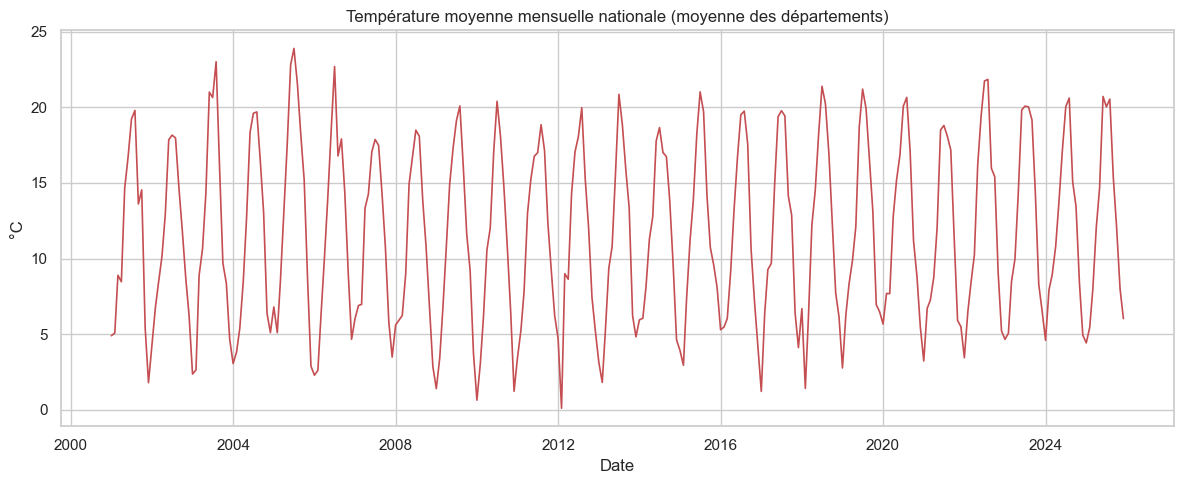

In [9]:
national = (
    final_df.groupby("date")["temp_moy_mensuelle"]
    .mean()
    .reset_index(name="temp_moy_nationale")
)

fig, ax = plt.subplots()
ax.plot(national["date"], national["temp_moy_nationale"], linewidth=1.2, color="#c44e52")
ax.set_title("Température moyenne mensuelle nationale (moyenne des départements)")
ax.set_xlabel("Date")
ax.set_ylabel("°C")
plt.tight_layout()
plt.show()


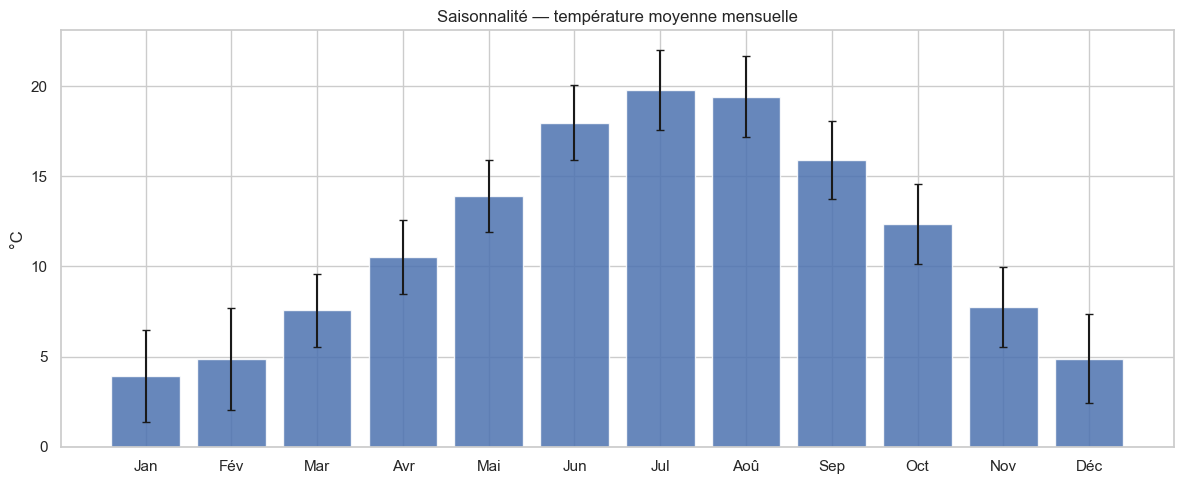

In [10]:
seasonal = final_df.groupby("mois")["temp_moy_mensuelle"].agg(["mean", "std"]).reset_index()
month_labels = ["Jan", "Fév", "Mar", "Avr", "Mai", "Jun", "Jul", "Aoû", "Sep", "Oct", "Nov", "Déc"]

fig, ax = plt.subplots()
ax.bar(seasonal["mois"], seasonal["mean"], yerr=seasonal["std"], capsize=3, color="#4c72b0", alpha=0.85)
ax.set_xticks(seasonal["mois"])
ax.set_xticklabels(month_labels)
ax.set_title("Saisonnalité — température moyenne mensuelle")
ax.set_ylabel("°C")
plt.tight_layout()
plt.show()


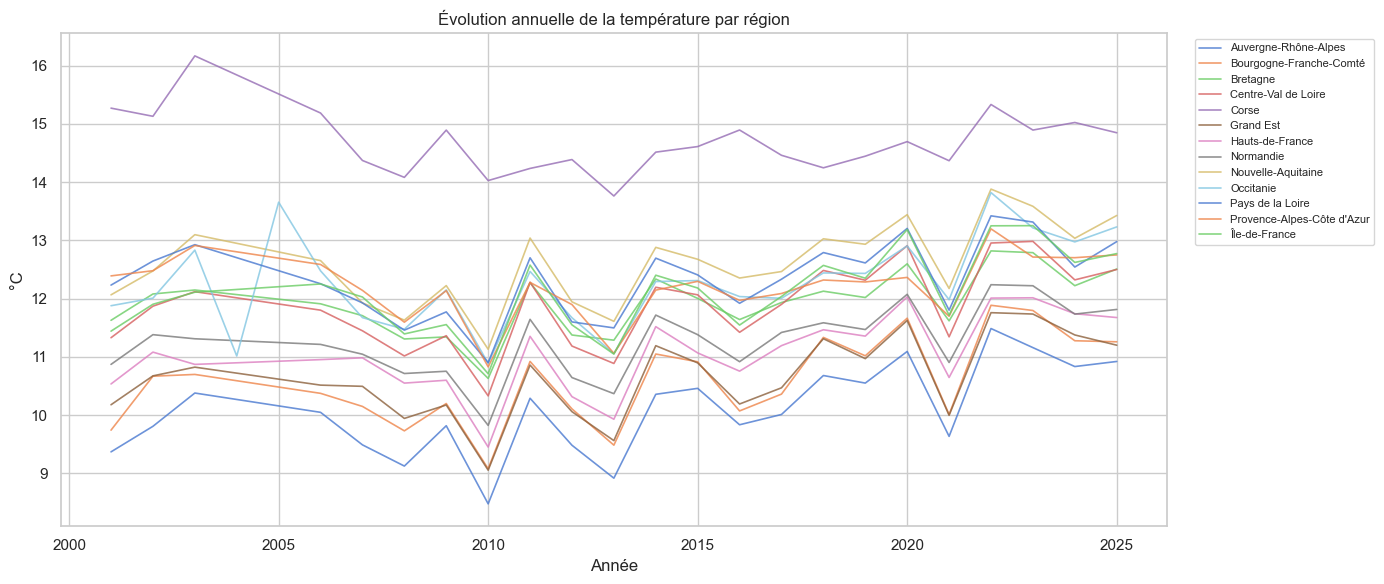

In [11]:
regional = (
    final_df.groupby(["nom_region", "annee"])["temp_moy_mensuelle"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
for region, grp in regional.groupby("nom_region"):
    ax.plot(grp["annee"], grp["temp_moy_mensuelle"], label=region, linewidth=1.2, alpha=0.8)
ax.set_title("Évolution annuelle de la température par région")
ax.set_xlabel("Année")
ax.set_ylabel("°C")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


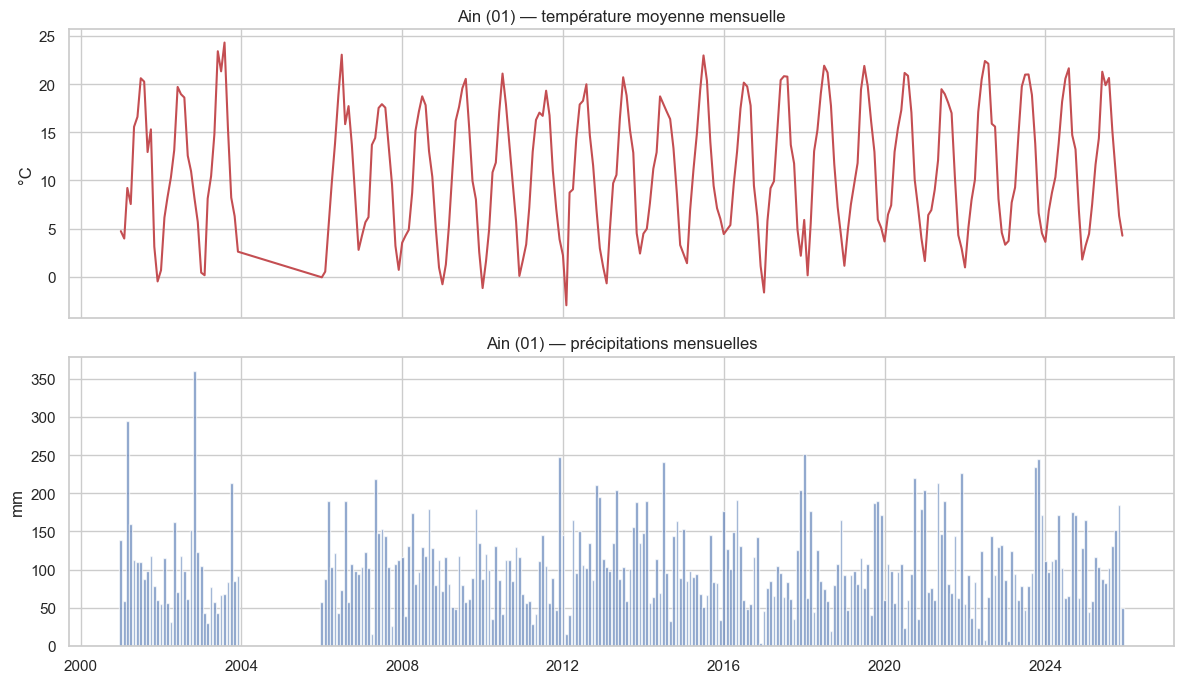

In [12]:
sample = final_df[final_df["code_departement"] == "01"].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(sample["date"], sample["temp_moy_mensuelle"], color="#c44e52")
axes[0].set_title("Ain (01) — température moyenne mensuelle")
axes[0].set_ylabel("°C")
axes[1].bar(sample["date"], sample["precipitations_mm"], width=25, color="#4c72b0", alpha=0.7)
axes[1].set_title("Ain (01) — précipitations mensuelles")
axes[1].set_ylabel("mm")
plt.tight_layout()
plt.show()


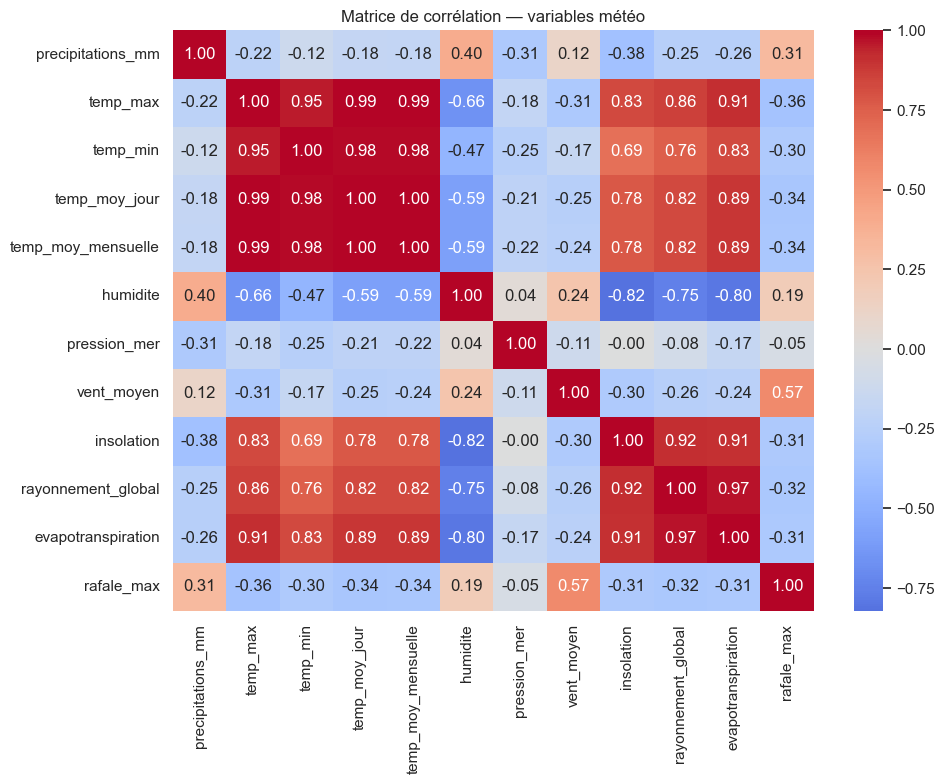

In [13]:
corr_cols = [c for c in VARIABLES if final_df[c].notna().sum() > 100]
corr = final_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matrice de corrélation — variables météo")
plt.tight_layout()
plt.show()


## 10. Export — fichier source unique

Ce fichier CSV constitue la **source unique** pour l'étape de feature engineering (lags, features calendaires, encodage géographique, etc.).

| Critère | Valeur |
|---------|--------|
| Granularité | département × mois |
| Qualité | Q = 1 uniquement |
| Période | > 2000, séries complètes (12 mois) |
| Enrichissement | région + nom département |


In [14]:
final_df.to_csv(EXPORT_CSV, index=False)

print(f"Dataset exporté : {EXPORT_CSV}")
print(f"Dimensions : {final_df.shape[0]:,} lignes × {final_df.shape[1]} colonnes")

synthese = pd.Series(
    {
        "observations": len(final_df),
        "departements": final_df["code_departement"].nunique(),
        "regions": final_df["nom_region"].nunique(),
        "annee_min": int(final_df["annee"].min()),
        "annee_max": int(final_df["annee"].max()),
        "temp_moy_nationale": round(final_df["temp_moy_mensuelle"].mean(), 2),
    },
    name="valeur",
)
display(synthese.to_frame())
final_df.head(3)


Dataset exporté : C:\Users\MASTER DATA&IA\Desktop\YNOV\Hackathon\src\data\processed\climat_source.csv
Dimensions : 25,560 lignes × 19 colonnes


,valeur
observations,25560.00
departements,95.00
regions,13.00
annee_min,2001.00
annee_max,2025.00
temp_moy_nationale,11.57


,code_departement,nom_departement,code_region,nom_region,annee,mois,date,precipitations_mm,temp_max,temp_min,temp_moy_jour,temp_moy_mensuelle,humidite,pression_mer,vent_moyen,insolation,rayonnement_global,evapotranspiration,rafale_max
0,01,Ain,84,Auvergne-Rhône-Alpes,2001,1,2001-01-01,138.509302,7.172727,1.390909,4.268182,4.750000,83.2,1014.60,2.075,2329.0,10532.0,21.700000,20.00
1,01,Ain,84,Auvergne-Rhône-Alpes,2001,2,2001-02-01,58.379070,8.836364,0.395455,4.622727,3.983333,75.6,1020.55,2.350,6132.0,20581.5,31.152381,19.75
2,01,Ain,84,Auvergne-Rhône-Alpes,2001,3,2001-03-01,294.341860,13.336364,5.545455,9.436364,9.225000,81.4,1008.85,2.225,5919.0,22483.0,47.852381,20.00
